In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_original = pd.read_csv(r'E:\Learnova\Project 2 Housing Price Predition using LR\notebooks\data\Housing.csv')

In [5]:
df_original

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [6]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


1. 544 rows and 13 columns
2. 6 int64 types(numerical) and 7 catagorical data 

In [7]:
df_original.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
# First 10 entries of dataset
df_original.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
# Last 10 entries of dataset
df_original.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [10]:
df_original.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

1. 'price': The price of the house (target variable).
2. 'area': The area or size of the house in square feet.
3. 'bedrooms': The number of bedrooms in the house.
4. 'bathrooms': The number of bathrooms in the house.
5. 'stories': The number of stories or floors in the house.
6. 'mainroad': Categorical variable indicating whether the house is located near the main road or not.
7. 'guestroom': Categorical variable indicating whether the house has a guest room or not.
8. 'basement': Categorical variable indicating whether the house has a basement or not.
9. 'hotwaterheating': Categorical variable indicating whether the house has hot water heating or not.
10. 'airconditioning': Categorical variable indicating whether the house has air conditioning or not.
11. 'parking': The number of parking spaces available with the house.
12. 'prefarea': Categorical variable indicating whether the house is in a preferred area or not.
13. 'furnishingstatus': The furnishing status of the house (e.g., unfurnished, semi-furnished, fully furnished).


In [11]:
# Getting all numerical columns in single dataframe
numerical_columns=df_original.select_dtypes(include=np.number)
numerical_columns

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [12]:
# Getting all catagorical columns in single dataframe
catagorical_column = df_original.select_dtypes(include=['str','category'])
catagorical_column

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
0,yes,no,no,no,yes,yes,furnished
1,yes,no,no,no,yes,no,furnished
2,yes,no,yes,no,no,yes,semi-furnished
3,yes,no,yes,no,yes,yes,furnished
4,yes,yes,yes,no,yes,no,furnished
...,...,...,...,...,...,...,...
540,yes,no,yes,no,no,no,unfurnished
541,no,no,no,no,no,no,semi-furnished
542,yes,no,no,no,no,no,unfurnished
543,no,no,no,no,no,no,furnished


In [13]:
# Checking null values 
df_original.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [14]:
df_original.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

No nan/null values in dataset

In [15]:
df_original.duplicated().sum()

np.int64(0)

No duplicate entries in dataset

In [16]:
def hist_plot(df:pd.DataFrame,column:'str'):
    plt.figure()
    sns.histplot(data=df,x=column,bins=30,kde=True)
    plt.title(f"Distribution of {column.title()}", fontsize=14, pad=10)
    plt.xlabel(column.title(), fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.tight_layout()
    plt.show()

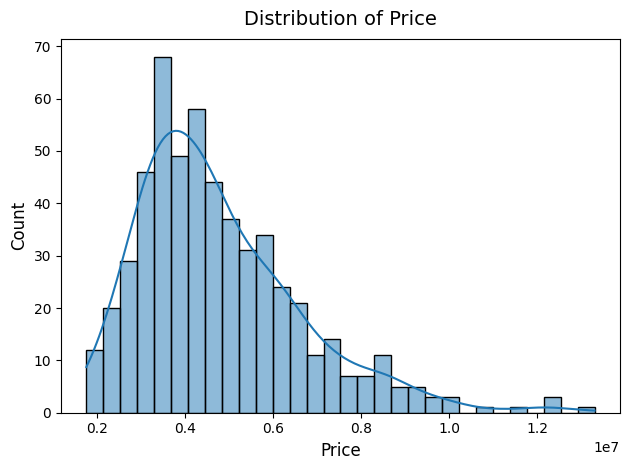

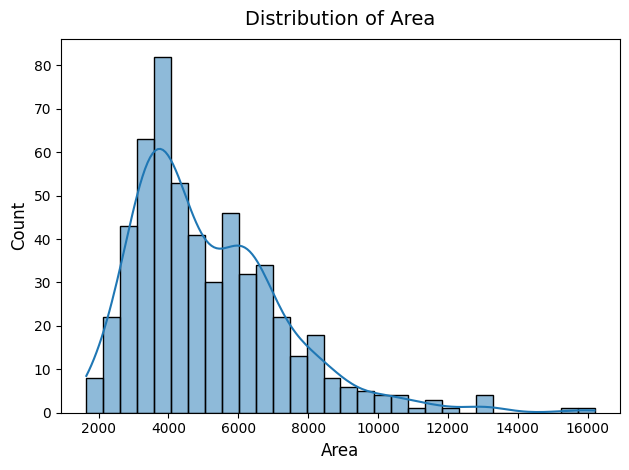

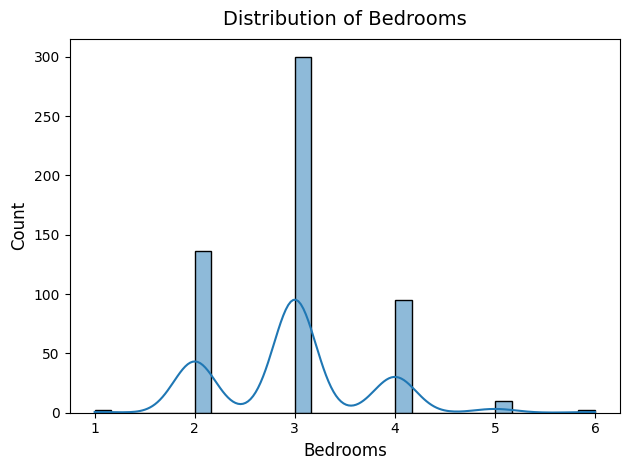

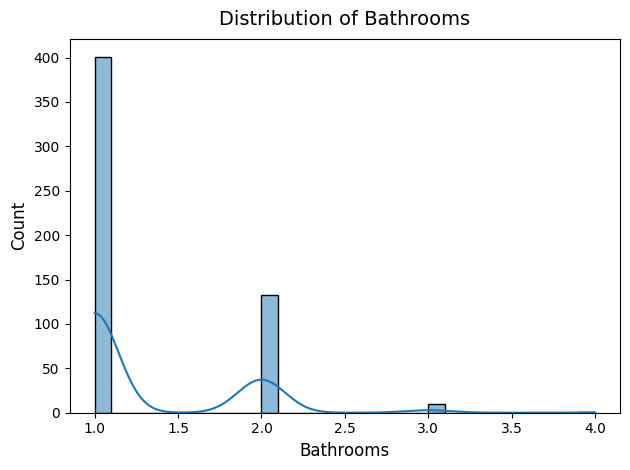

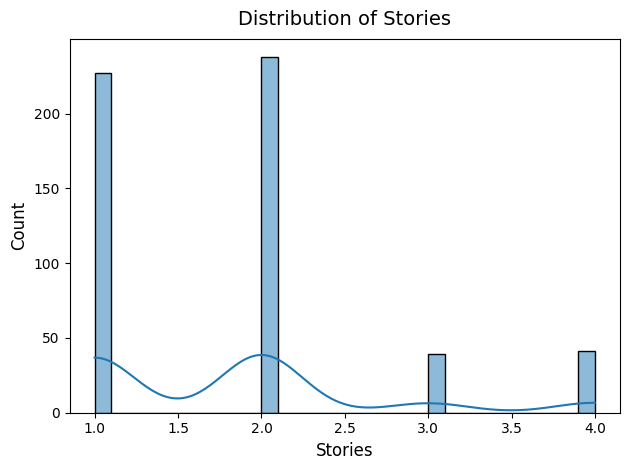

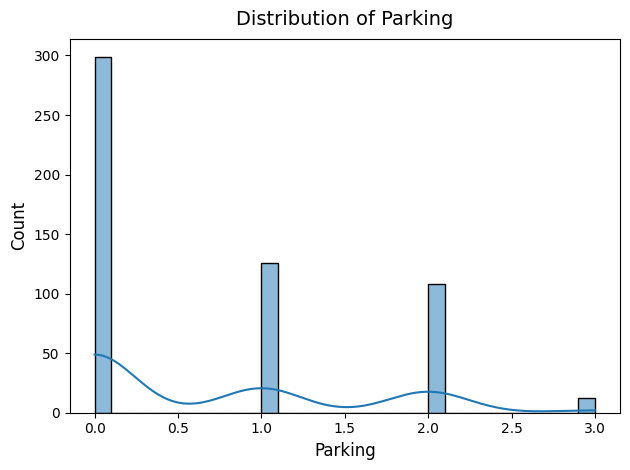

In [17]:
for col in numerical_columns.columns:
    hist_plot(numerical_columns,col)

Since Parking,Stories,Bathrooms and Bedroom are discrete values use count plot for those columns

In [18]:
def count_plot(df:pd.DataFrame,column:'str'):
    plt.figure()
    sns.countplot(data=df,x=column)
    plt.title(f"Distribution of {column.title()}", fontsize=14, pad=10)
    plt.xlabel(column.title(), fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.tight_layout()
    plt.show()

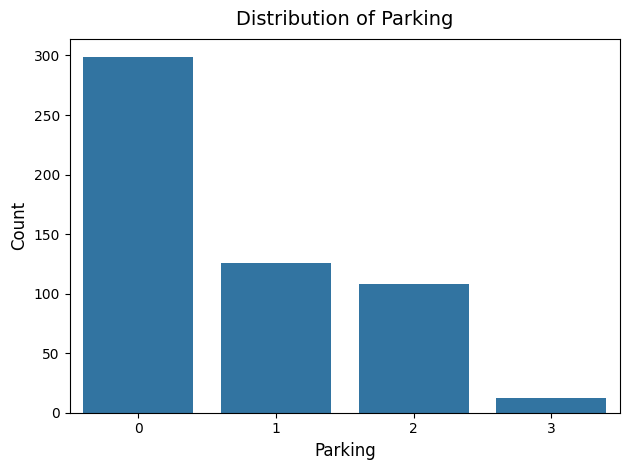

In [19]:
count_plot(df_original,column='parking')

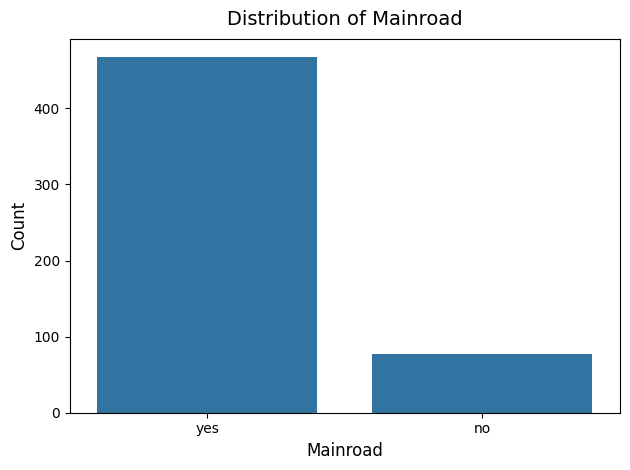

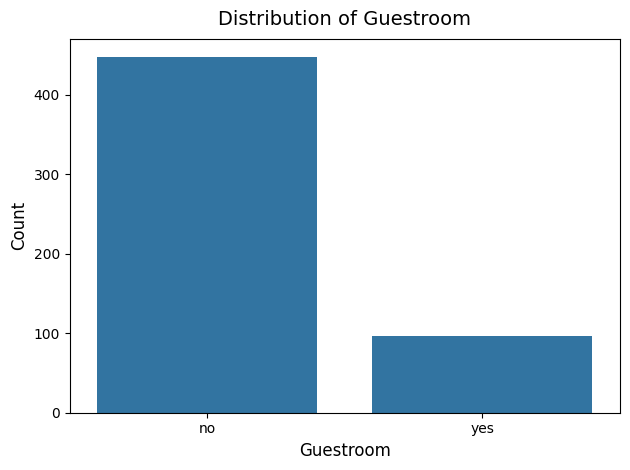

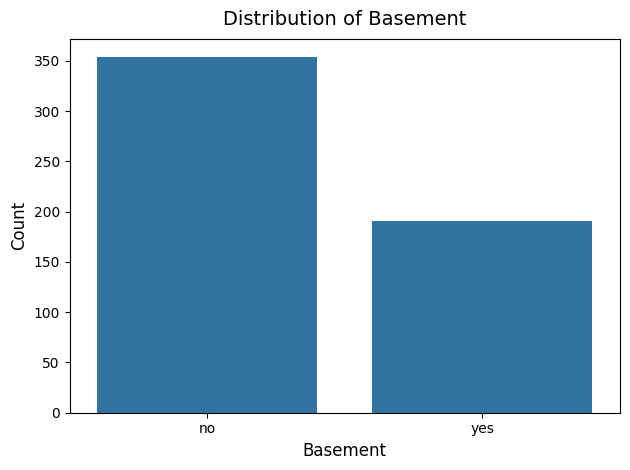

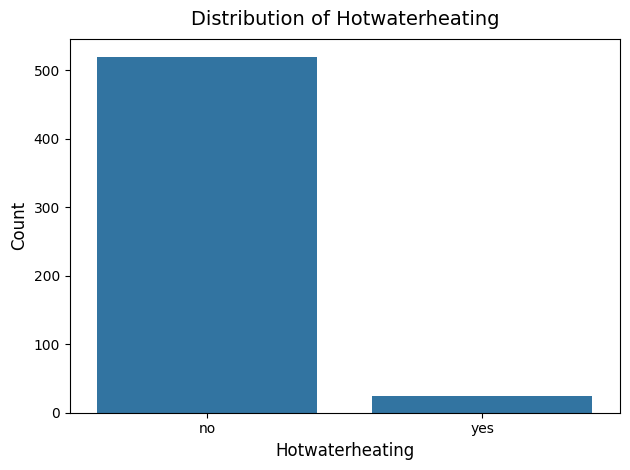

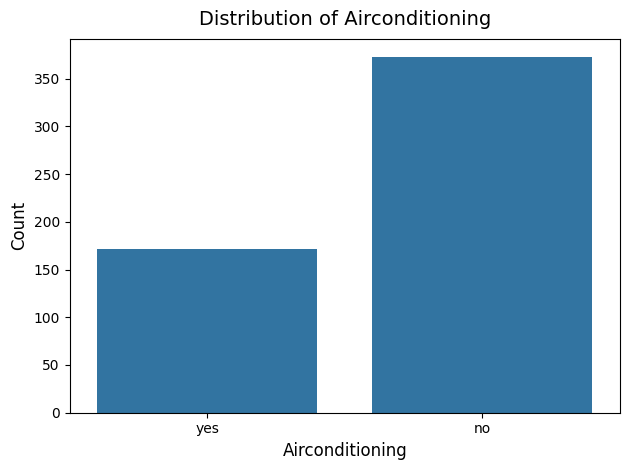

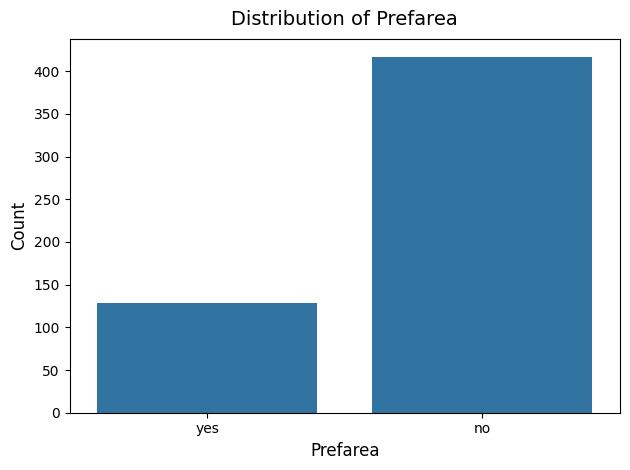

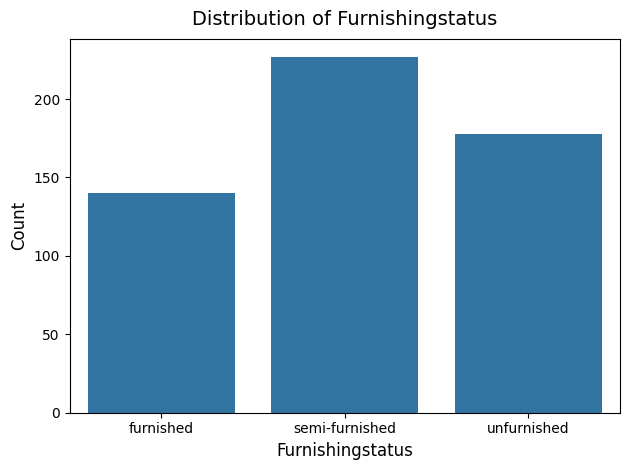

In [20]:
for col in catagorical_column.columns:
    count_plot(catagorical_column,col)

In [21]:
corre = numerical_columns.corr()
corre

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


<Axes: >

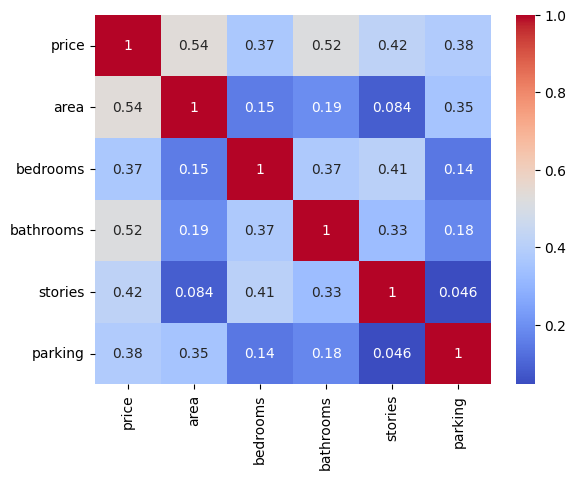

In [22]:
sns.heatmap(corre,annot=True, cmap='coolwarm')

In [23]:
numerical_columns['bedrooms'].nunique()

6

<Axes: xlabel='area', ylabel='price'>

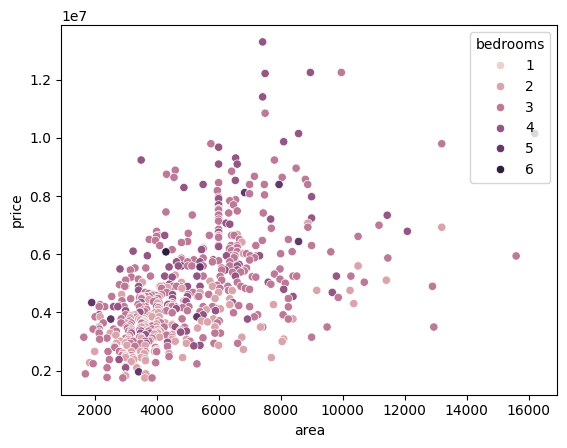

In [24]:
sns.scatterplot(data=df_original,x='area',y='price',hue='bedrooms')

<Axes: xlabel='area'>

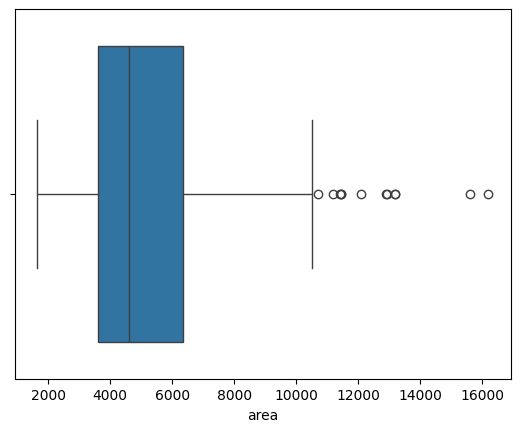

In [25]:
# Detecting outlires
sns.boxplot(data=df_original,x='area',legend='auto')

In [52]:
def box_plots(df:pd.DataFrame,column):
    plt.figure(figsize=(8, 4))
    # Putting the discrete variable on the X-axis spreads the boxes out cleanly
    sns.boxplot(data=df_original, x=column, y="price", palette="pastel",legend=False,hue='stories')
    plt.title(f"Checking Price Outliers Across House w.r.t {column}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

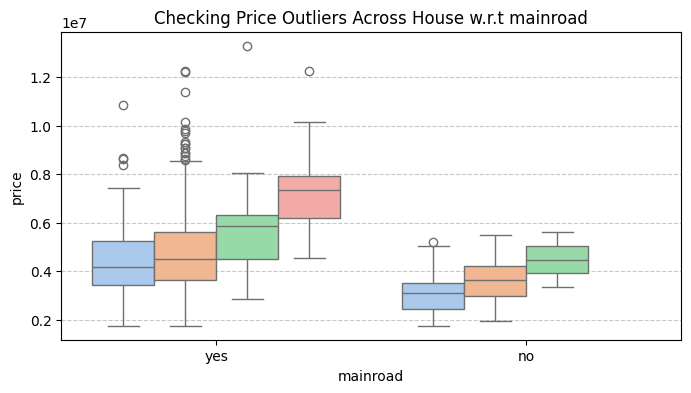

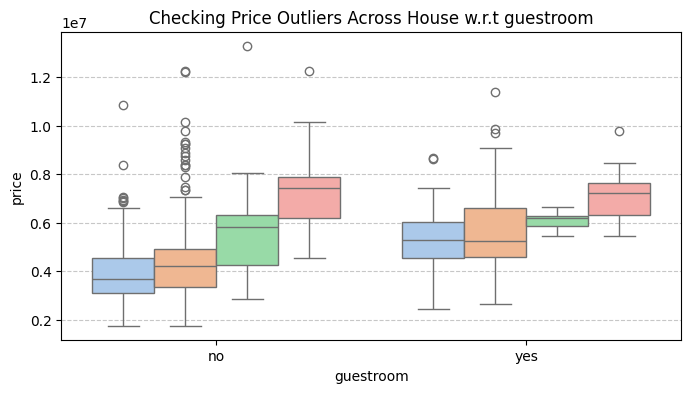

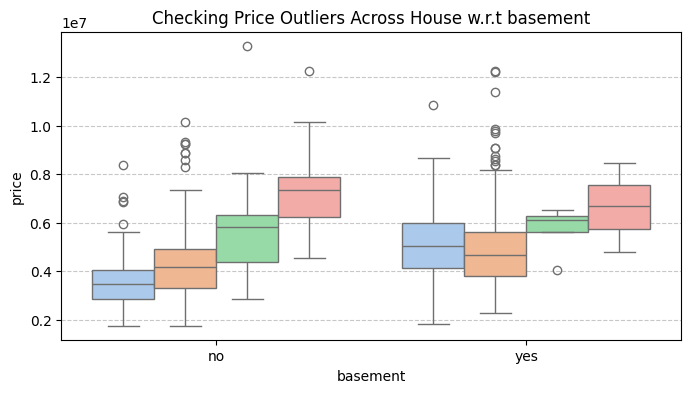

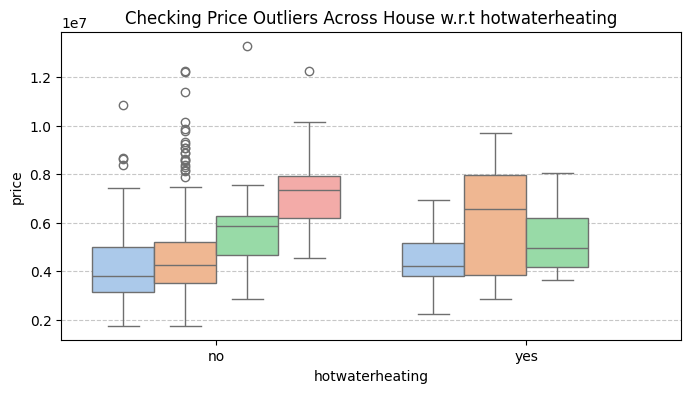

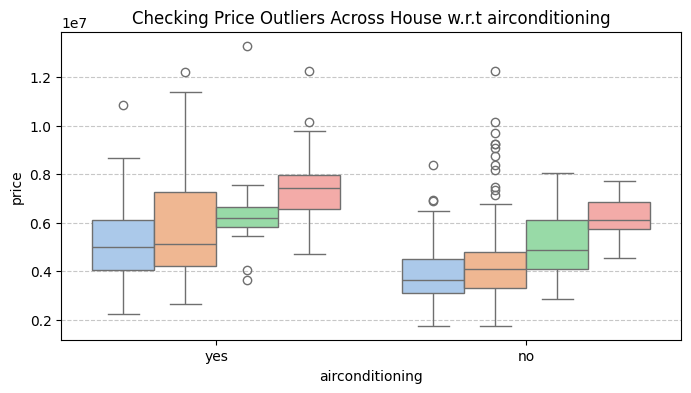

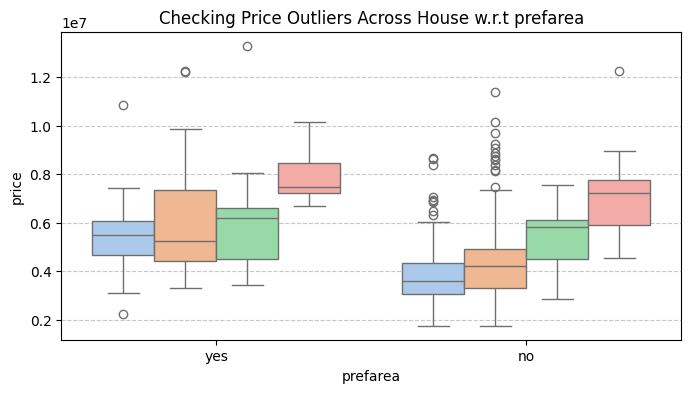

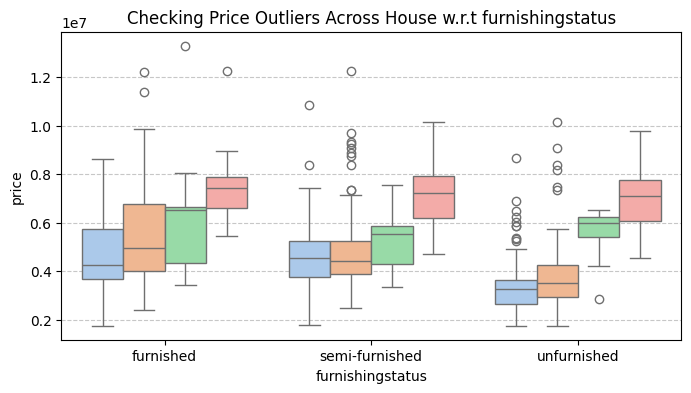

In [53]:
for col in catagorical_column:
    box_plots(catagorical_column,col)

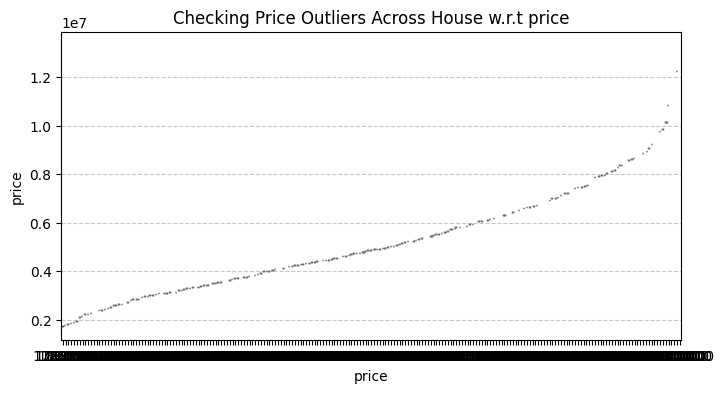

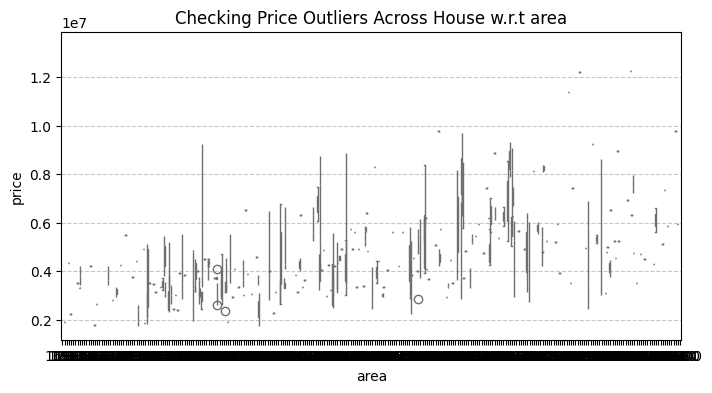

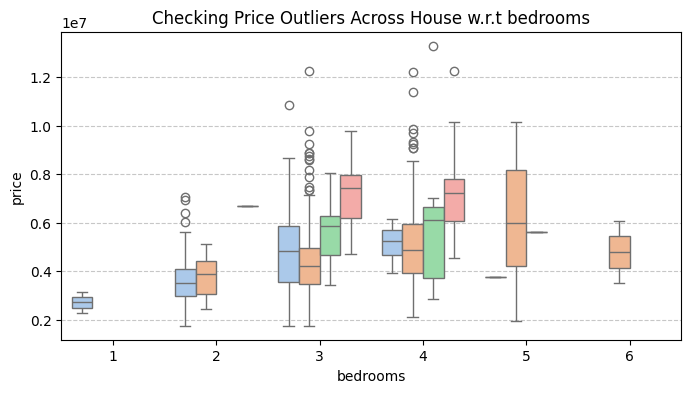

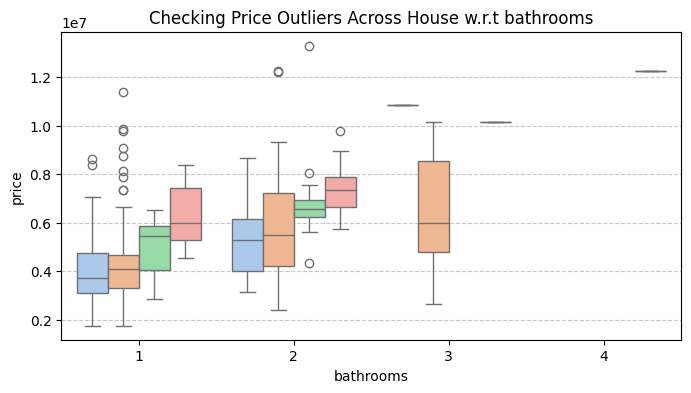

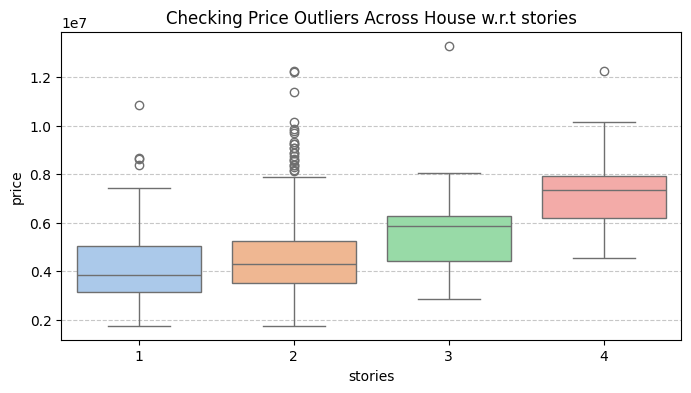

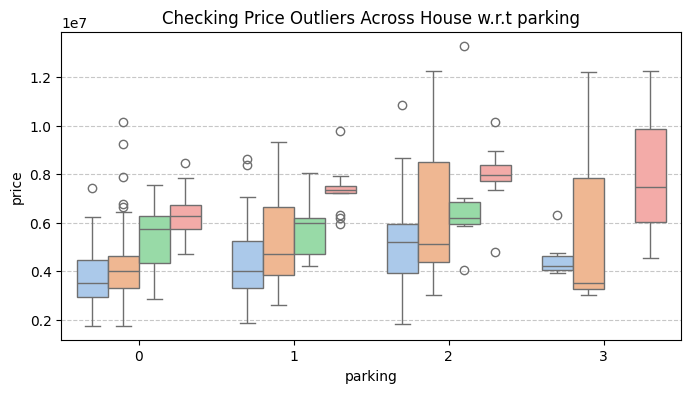

In [46]:
for col in numerical_columns:
    box_plots(numerical_columns,col)

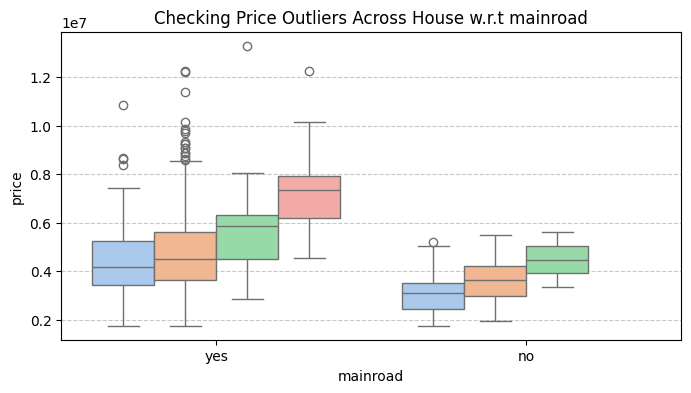

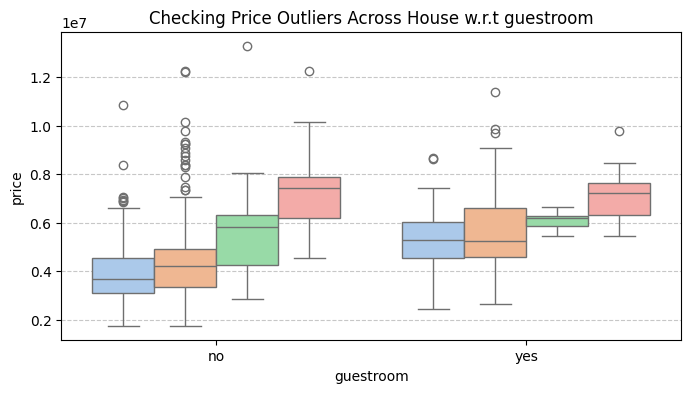

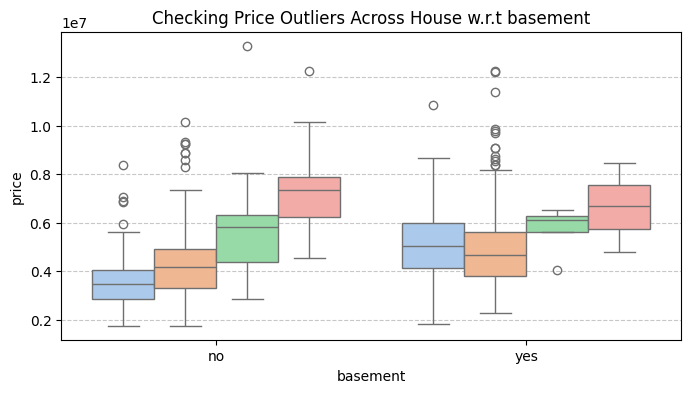

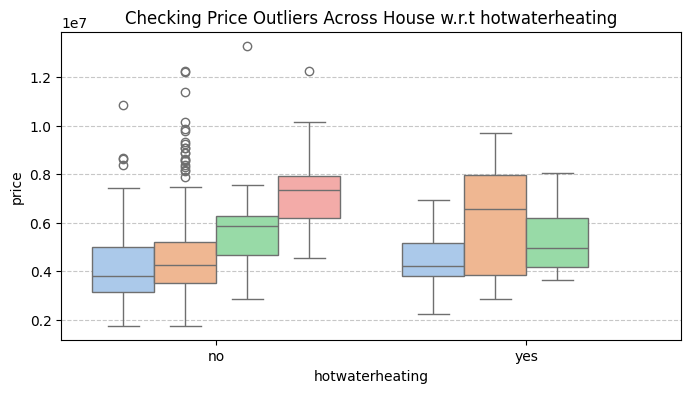

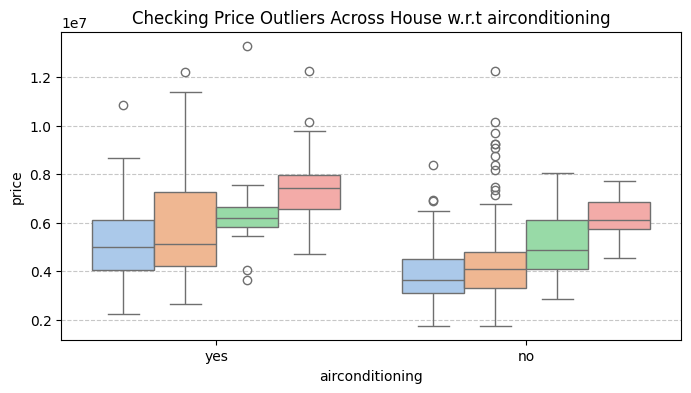

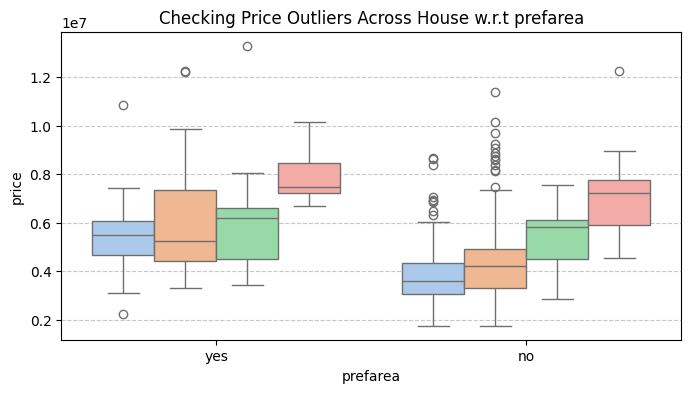

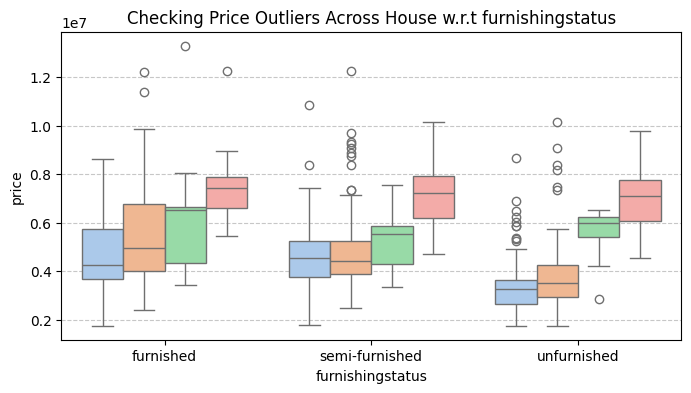

In [54]:
for col in catagorical_column:
    box_plots(catagorical_column,col
              )

In [43]:
upper = corre.where(np.triu(np.ones(corre.shape), k=1).astype(bool))

high_corr = [column for column in upper.columns if any(upper[column].abs() > 0.7)]

print(high_corr)

[]


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Select only your independent numeric features (Make sure to DROP 'price')
X_features = df_original.select_dtypes(include=["number"]).drop(
    columns=["price"]
)

# 2. Add a constant column (VIF math requires an intercept)
X_features["intercept"] = 1

# 3. Calculate VIF for each feature
vif_data = []
for i in range(X_features.shape[1] - 1):  # exclude the intercept from print
    vif_val = variance_inflation_factor(X_features.values, i)
    vif_data.append({"Feature": X_features.columns[i], "VIF": vif_val})

# 4. Display results cleanly
vif_df = pd.DataFrame(vif_data).sort_values(by="VIF", ascending=False)
print(vif_df)

     Feature       VIF
1   bedrooms  1.316597
3    stories  1.255202
2  bathrooms  1.252775
0       area  1.170959
4    parking  1.164172


As VIF score for each features is less then 5, Above results ensures there is no multi collunearity problem in dataset.

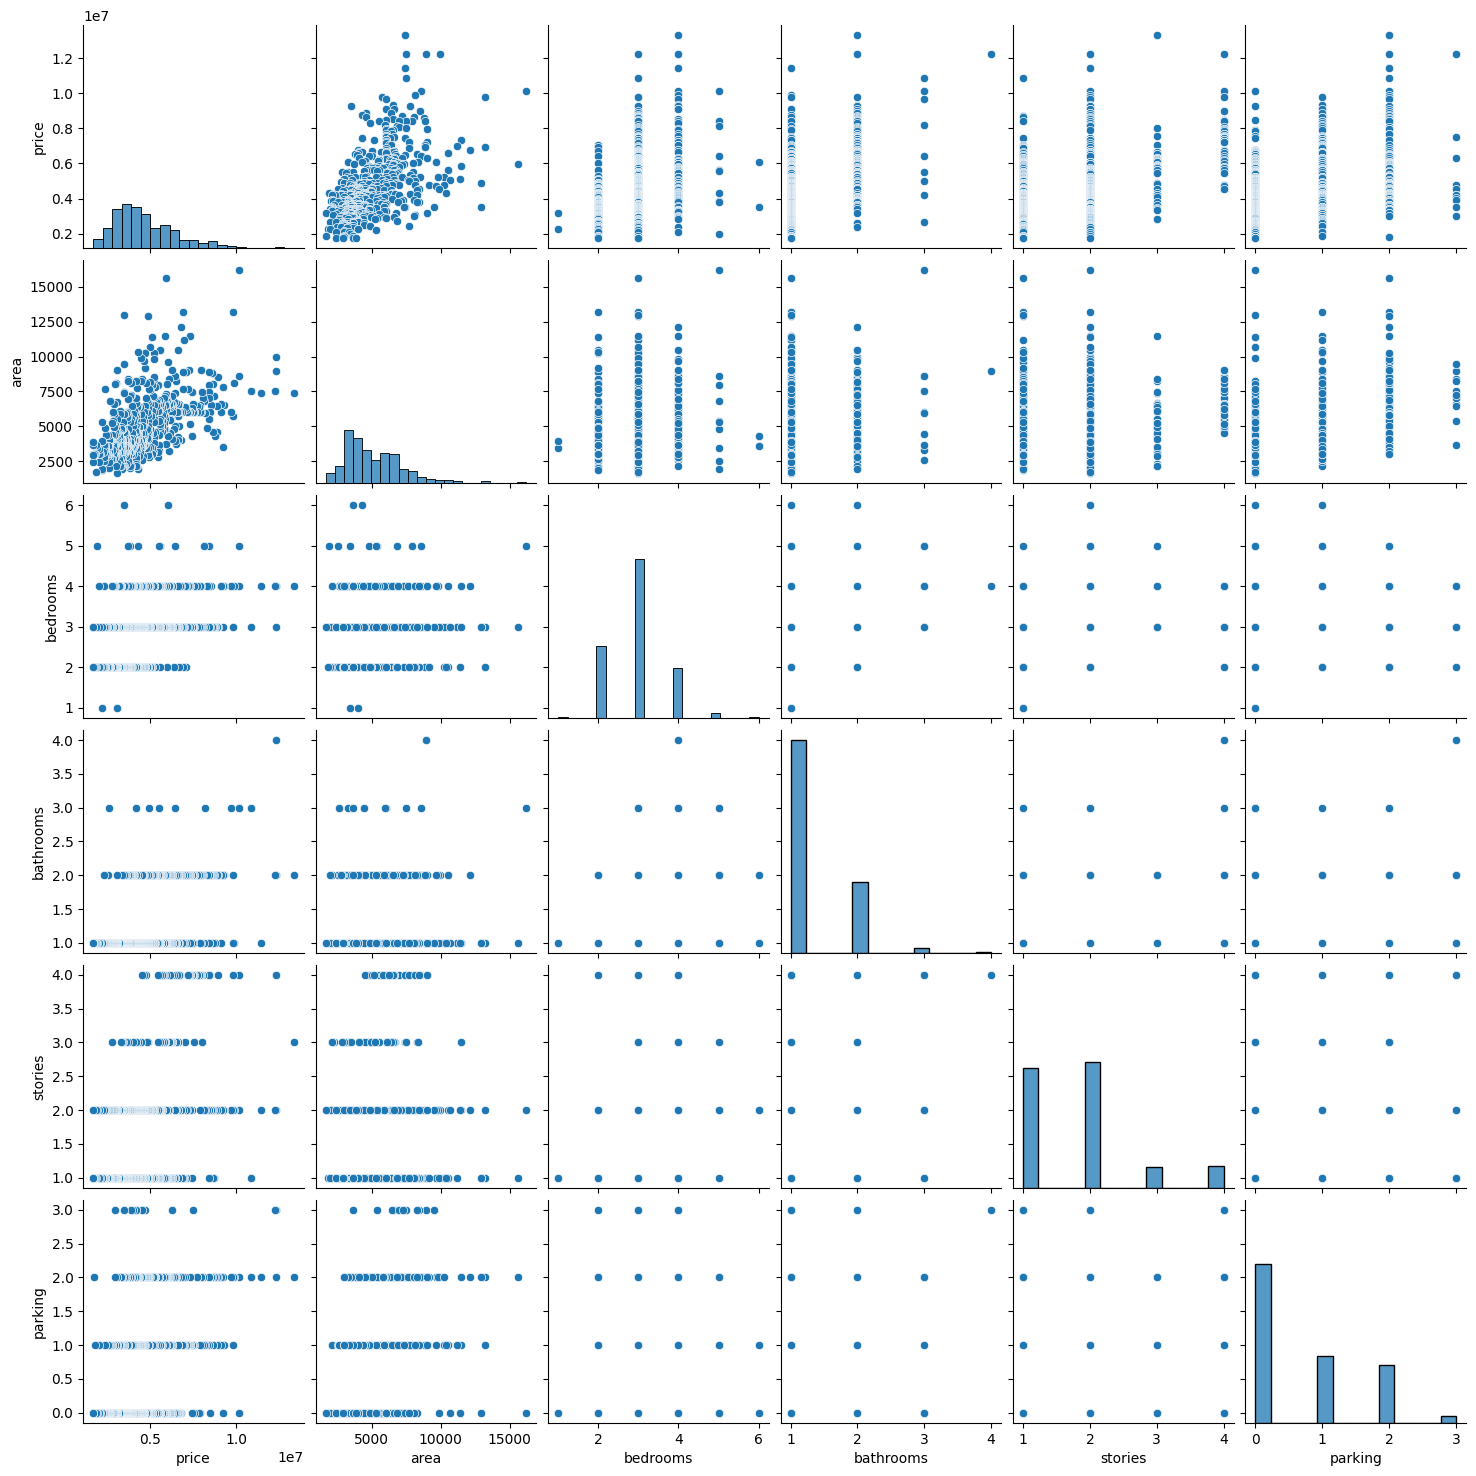

In [ ]:
sns.pairplot(data=df_original)